# 📊 Analyse Exploratoire des Données (EDA)
**Dataset :** MovieLens Latest Small — 9742 films, 100 836 notes, 610 utilisateurs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('dark_background')
sns.set_palette('Reds_r')
print('✅ Librairies importées !')

✅ Librairies importées !


In [2]:
# Chargement des données
ratings = pd.read_csv('../data/ratings.csv')
movies  = pd.read_csv('../data/movies.csv')

print(f'🎬 Films     : {len(movies):,}')
print(f'⭐ Notes     : {len(ratings):,}')
print(f'👤 Utilisateurs : {ratings["userId"].nunique()}')
print()
print(movies.head())
print()
print(ratings.head())

🎬 Films     : 9,742
⭐ Notes     : 100,836
👤 Utilisateurs : 610

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931


## 1. Distribution des notes

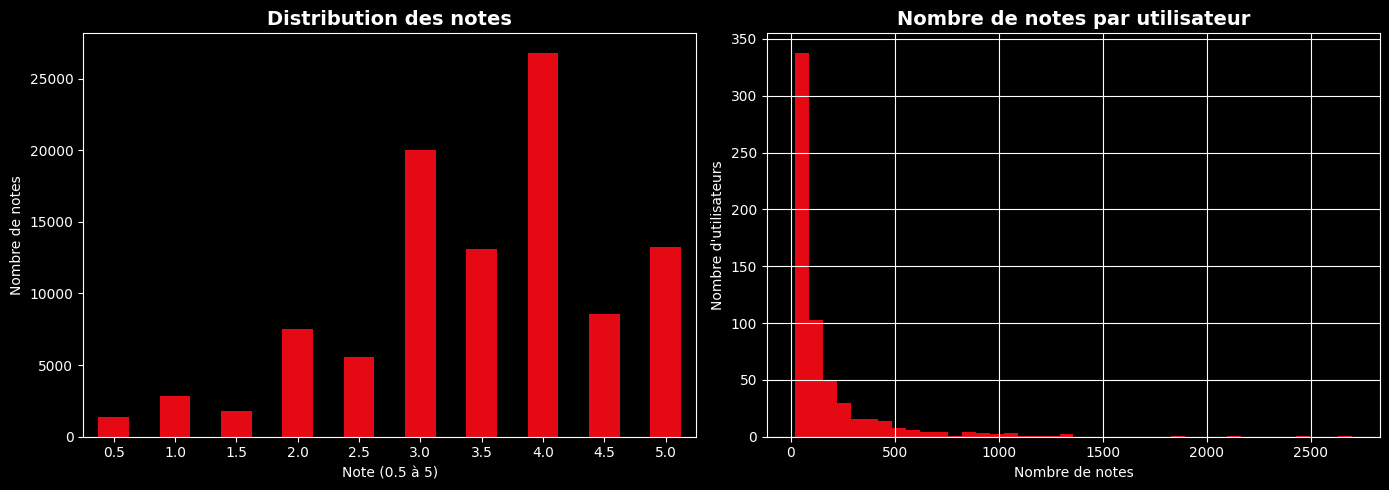

Note moyenne : 3.50
Note médiane : 3.5
Écart-type   : 1.04


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution des notes
ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='#E50914', edgecolor='none'
)
axes[0].set_title('Distribution des notes', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Note (0.5 à 5)')
axes[0].set_ylabel('Nombre de notes')
axes[0].tick_params(rotation=0)

# Notes par utilisateur
notes_par_user = ratings.groupby('userId').size()
notes_par_user.hist(bins=40, ax=axes[1], color='#E50914', edgecolor='none')
axes[1].set_title('Nombre de notes par utilisateur', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Nombre de notes')
axes[1].set_ylabel('Nombre d\'utilisateurs')

plt.tight_layout()
plt.savefig('../data/distribution_notes.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Note moyenne : {ratings["rating"].mean():.2f}')
print(f'Note médiane : {ratings["rating"].median()}')
print(f'Écart-type   : {ratings["rating"].std():.2f}')

## 2. Films les mieux notés

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14492\266796104.py:19: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_14492\266796104.py:20: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('../data/top10_films.png', dpi=150, bbox_inches='tight')
C:\Users\ASUS\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


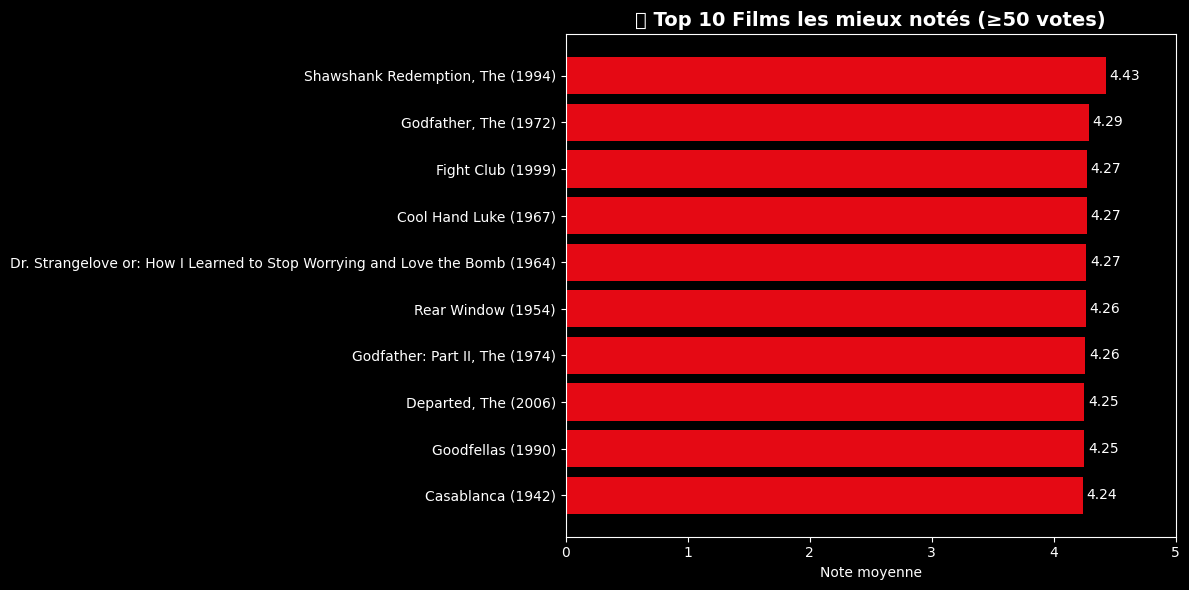

                                                    count      mean
title                                                              
Shawshank Redemption, The (1994)                      317  4.429022
Godfather, The (1972)                                 192  4.289062
Fight Club (1999)                                     218  4.272936
Cool Hand Luke (1967)                                  57  4.271930
Dr. Strangelove or: How I Learned to Stop Worry...     97  4.268041
Rear Window (1954)                                     84  4.261905
Godfather: Part II, The (1974)                        129  4.259690
Departed, The (2006)                                  107  4.252336
Goodfellas (1990)                                     126  4.250000
Casablanca (1942)                                     100  4.240000


In [4]:
df = ratings.merge(movies, on='movieId')

top_films = (
    df.groupby('title')['rating']
    .agg(count='count', mean='mean')
    .query('count >= 50')
    .sort_values('mean', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top_films.index[::-1], top_films['mean'][::-1], color='#E50914', edgecolor='none')
ax.set_xlabel('Note moyenne')
ax.set_title('🏆 Top 10 Films les mieux notés (≥50 votes)', fontsize=14, fontweight='bold')
ax.set_xlim(0, 5)
for bar, val in zip(bars, top_films['mean'][::-1]):
    ax.text(bar.get_width()+0.03, bar.get_y()+bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10)
plt.tight_layout()
plt.savefig('../data/top10_films.png', dpi=150, bbox_inches='tight')
plt.show()
print(top_films)

## 3. Analyse des genres

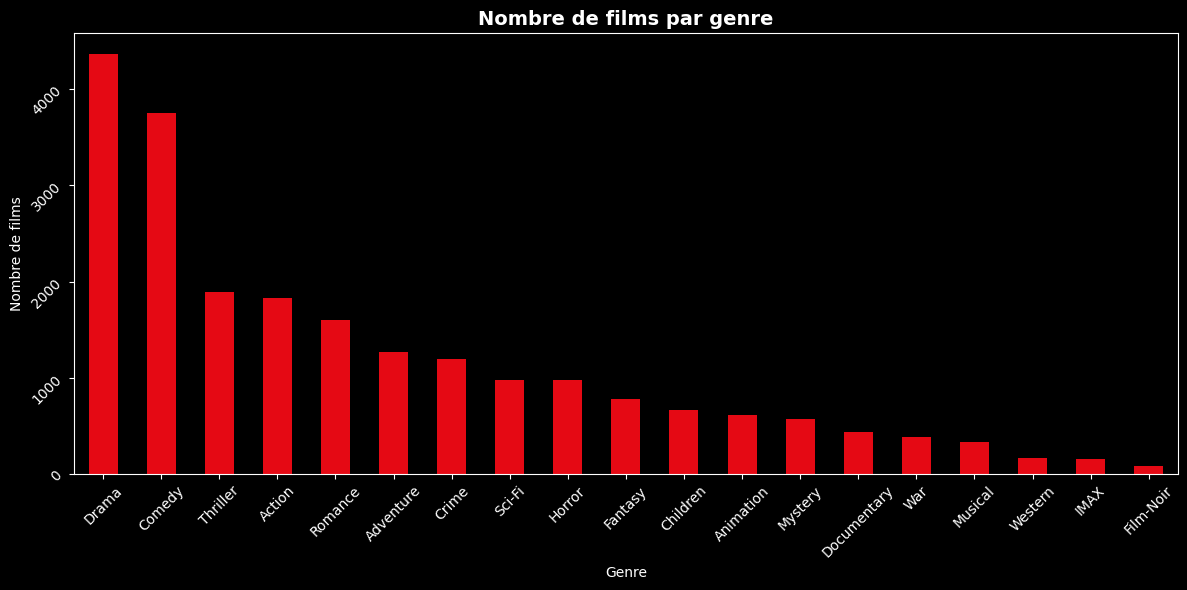

genres
Drama        4361
Comedy       3756
Thriller     1894
Action       1828
Romance      1596
Adventure    1263
Crime        1199
Sci-Fi        980
Horror        978
Fantasy       779
Name: count, dtype: int64


In [5]:
# Extraire les genres
genres_series = movies['genres'].str.split('|').explode()
genre_counts = genres_series.value_counts().drop('(no genres listed)', errors='ignore')

fig, ax = plt.subplots(figsize=(12, 6))
genre_counts.plot(kind='bar', ax=ax, color='#E50914', edgecolor='none')
ax.set_title('Nombre de films par genre', fontsize=14, fontweight='bold')
ax.set_xlabel('Genre')
ax.set_ylabel('Nombre de films')
ax.tick_params(rotation=45)
plt.tight_layout()
plt.savefig('../data/genres.png', dpi=150, bbox_inches='tight')
plt.show()
print(genre_counts.head(10))

## 4. Évolution temporelle

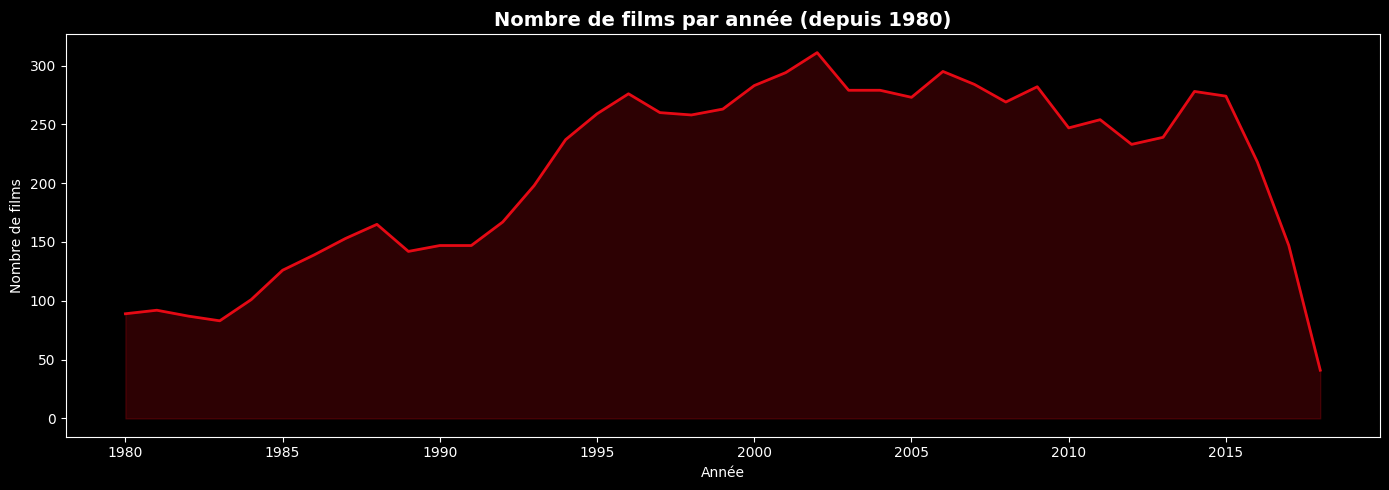

Année la plus représentée : 2002 (311 films)


In [6]:
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype(float)

films_par_an = movies.dropna(subset=['year']).groupby('year').size()

fig, ax = plt.subplots(figsize=(14, 5))
films_par_an[films_par_an.index >= 1980].plot(ax=ax, color='#E50914', linewidth=2)
ax.fill_between(films_par_an[films_par_an.index>=1980].index,
                films_par_an[films_par_an.index>=1980].values,
                alpha=0.2, color='#E50914')
ax.set_title('Nombre de films par année (depuis 1980)', fontsize=14, fontweight='bold')
ax.set_xlabel('Année')
ax.set_ylabel('Nombre de films')
plt.tight_layout()
plt.show()
print(f'Année la plus représentée : {int(films_par_an.idxmax())} ({int(films_par_an.max())} films)')

## 5. Matrice de densité

In [7]:
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
n_ratings = len(ratings)
density = n_ratings / (n_users * n_movies) * 100

print('=== Résumé du dataset ===')
print(f'Utilisateurs   : {n_users}')
print(f'Films          : {n_movies}')
print(f'Notes totales  : {n_ratings:,}')
print(f'Densité matrice: {density:.2f}%')
print(f'Sparsité       : {100-density:.2f}%')

=== Résumé du dataset ===
Utilisateurs   : 610
Films          : 9724
Notes totales  : 100,836
Densité matrice: 1.70%
Sparsité       : 98.30%
